In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline


# 1. Load Cleaned Data

In [2]:
df = pd.read_csv('../data/cleaned_data.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
df.shape
df.head()

,Timestamp,PV1_Current_A,PV2_Current_A,PV1_Voltage_V,PV2_Voltage_V,PV1_Power_W,PV2_Power_W,DC,Solar_Radiation_Wm2,Outdoor_Temp_C,...,Wind_Dir_deg,Pressure_hPa,Humidity_pct,UV_Index,Wind_Gust_ms,Rain_mm,AQI_US,PM25_ugm3,PM10_ugm3,PM1_ugm3
0,2026-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,10.192,...,293.500,1015.973,72.833,0.0,1.5,0.0,52.550,10.500,18.850,8.167
1,2026-01-01 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,10.008,...,320.083,1016.199,73.917,0.0,1.0,0.0,46.517,8.433,14.950,6.550
2,2026-01-01 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,9.875,...,321.000,1016.594,75.750,0.0,1.0,0.0,46.383,8.433,15.017,6.417
3,2026-01-01 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,9.367,...,321.000,1016.764,77.833,0.0,1.0,0.0,51.800,9.617,17.317,7.567
4,2026-01-01 04:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,8.925,...,321.583,1016.679,79.833,0.0,1.5,0.0,52.767,9.983,17.033,8.033


# 2. Diagnostic EDA

Goal: understand the raw data's quality and structure *before* deciding how to treat it. The findings here directly motivate the choices made in the Preprocessing notebook (daytime filtering, KNN imputation).

## Raw Time Series

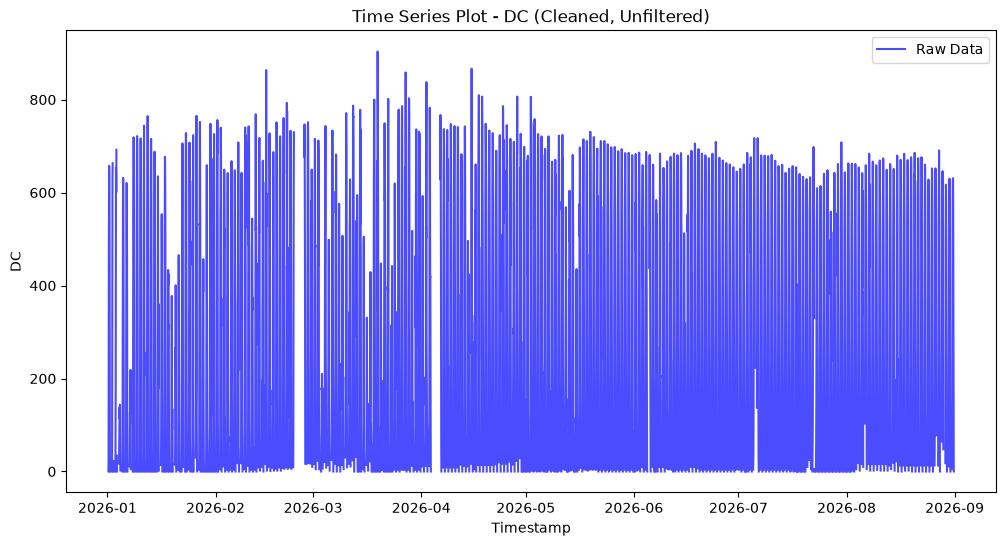

In [3]:
plt.figure(figsize=(12, 6))
plt.plot(df['Timestamp'], df['DC'], label="Raw Data", color="blue", alpha=0.7)
plt.xlabel("Timestamp")
plt.ylabel('DC')
plt.title("Time Series Plot - DC (Cleaned, Unfiltered)")
plt.legend()
plt.show()


## AC Power by Hour of Day

Checking whether AC output behaves differently across hours reveals whether nighttime readings are legitimate zeros/noise that should be excluded before imputation.

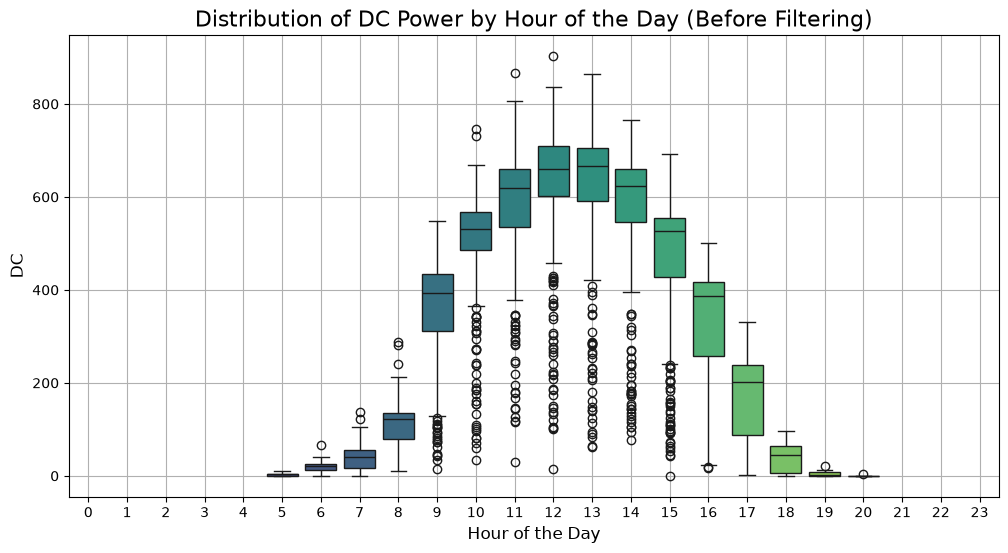

In [4]:
df['Hour_of_Day'] = df['Timestamp'].dt.hour

plt.figure(figsize=(12, 6))
sns.boxplot(
    x='Hour_of_Day',
    y='DC',
    hue='Hour_of_Day',
    data=df,
    palette='viridis',
    legend=False
)
plt.title('Distribution of DC Power by Hour of the Day (Before Filtering)', fontsize=16)
plt.xlabel('Hour of the Day', fontsize=12)
plt.ylabel('DC', fontsize=12)
plt.grid(True)
plt.show()

df.drop(columns=['Hour_of_Day'], inplace=True)


## Missing Values Overview

In [5]:
missing_values = df.isnull().sum()
print(missing_values)


Timestamp                 0
PV1_Current_A          2492
PV2_Current_A          2492
PV1_Voltage_V          2492
PV2_Voltage_V          2492
PV1_Power_W            2507
PV2_Power_W            2507
DC                     2507
Solar_Radiation_Wm2       0
Outdoor_Temp_C            0
Dew_Point_C               0
Wind_Speed_ms             0
Wind_Dir_deg              0
Pressure_hPa              0
Humidity_pct              0
UV_Index                  0
Wind_Gust_ms              0
Rain_mm                   0
AQI_US                   47
PM25_ugm3                47
PM10_ugm3                47
PM1_ugm3                 47
dtype: int64


### Takeaways

- AC power is zero outside daylight hours → restrict the dataset to sunrise–sunset before imputing.
- Several variables have non-trivial missing values → use a neighbor-based method (KNN imputation) that can leverage correlated features rather than a naive fill.

These decisions are implemented in `3_Preprocessing.ipynb`.